**Exploratory Data Analysis (verification)**

- Load the packages and the dataset "data_modeling.csv":

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/data_modeling.csv')

In [3]:
print(df.shape)

(330353, 8)


In [4]:
df.head()

,loan_id,default_flag,gross_approval,term_in_months,naics_code_2,project_state,size_bucket,processing_bucket
0,100355,0,3600000.0,300,44,GA,>2M,STANDARD
1,149575,0,194000.0,120,72,WA,150-350k,PLP
2,112535,0,475000.0,204,44,WA,350-2M,PLP
3,191778,0,90000.0,84,45,ME,50-150k,PLP
4,206293,0,1300000.0,300,45,NJ,350-2M,PLP


- Check balance of Default and No Default:

In [5]:
print("Tasa de default:", df["default_flag"].mean())
print(df["default_flag"].value_counts(normalize=True))

Tasa de default: 0.0113121418603736
default_flag
0    0.988688
1    0.011312
Name: proportion, dtype: float64


*Just like in SQL, we can see that the dataset is unbalanced: ~1.1% of the loans are in default*

- Distribution of loan amounts:

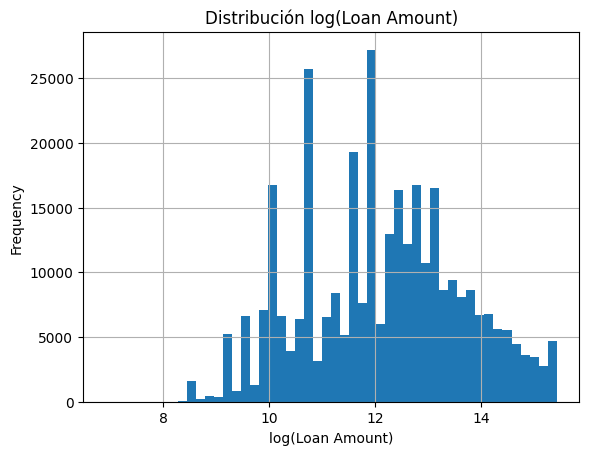

In [6]:
df["log_loan_amount"] = np.log1p(df["gross_approval"])
df["log_loan_amount"].hist(bins=50)
plt.title("Distribución log(Loan Amount)")
plt.xlabel("log(Loan Amount)")
plt.ylabel("Frequency")
plt.show()

The histogram shows the distribution of loans by total amount borrowed. Once again, it confirms a skew in the loan amount distribution toward lower values: 0–150k > 350k–2M


- Distribution of loan terms in months:

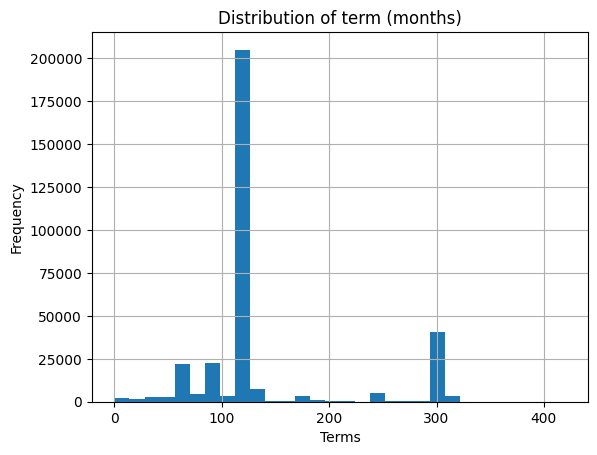

In [7]:
df["term_in_months"].hist(bins=30)
plt.title("Distribution of term (months)")
plt.xlabel("Terms")
plt.ylabel("Frequency")
plt.show()


*We can see that the loan terms are highly concentrated around 120 months (≈ 8 years)*

- Probability of default by state:

In [8]:
odr_state = df.groupby("project_state")["default_flag"].mean().sort_values(ascending=False).head(10)
print(odr_state)

project_state
NV    0.018089
LA    0.017221
FL    0.016325
NY    0.016122
HI    0.015099
CA    0.014397
IL    0.013942
SD    0.013937
NJ    0.013796
AZ    0.013762
Name: default_flag, dtype: float64


*We confirm that the results are the same as in SQL, with Nevada, Los Angeles, and Florida as the states with the highest default rates*


- Default rate by sector:

In [9]:
odr_naics = df.groupby("naics_code_2")["default_flag"].mean().sort_values(ascending=False).head(10)
print(odr_naics)

naics_code_2
48    0.025142
22    0.016949
49    0.016931
42    0.013520
23    0.013287
56    0.013210
45    0.012725
53    0.011712
54    0.010989
61    0.010863
Name: default_flag, dtype: float64


*Checking by sector, the results are the same, showing a clear gap in the default rate of the Transportation-Storage sector compared to the other sectors*

**Logistic Model (PD)**

- Load the packages needed to build the model:

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

- Testing a logit model with AUROC and KS:

The following model predicts the probability of default (PD) using the binary dependent variable 'default_flag' together with the regressors known at the time of loan origination (before default):  

- Loan amount (gross_approval in logarithmic scale)  
- Loan term (term_in_months)  
- Economic sector (naics_code_2)  
- State (project_state)  
- Loan amount range (size_bucket)  
- Loan program type (processing_bucket)  

Loan term and loan amount are kept as numeric variables (as they currently are), while categorical variables are converted into dummies (binary indicators).


For training the model, we set class_weight='balanced' so that loans in default (~1.1% of total loans) receive a higher weight. This prevents the PD from being equal to 0, since the data is unbalanced and a correction is required.


Next, the dataset is split into 80% training and 20% test, which helps prevent the model from memorizing the dataset and producing a biased prediction (overfitting).

We evaluate the model by calculating the **AUC** (Area Under the ROC Curve), which measures how well the model distinguishes default vs. no default, and the **KS** (Kolmogorov–Smirnov), which measures the separation between good and bad clients.

Finally, a **pd_score** (probability of default) is calculated for each loan. Loans are sorted by PD and divided into 10 groups (deciles). For each decile we measure: number of loans, number of defaults, default rate (ODR), cumulative % of defaults, and volume. The model automatically exports `pd_scores.csv` and `decile_summary.csv` to the */outputs* folder.


In [11]:
df = pd.read_csv('../data/data_modeling.csv')
df['log_loan_amount'] = np.log1p(df['gross_approval'])

X = df[['log_loan_amount','term_in_months','naics_code_2','project_state','size_bucket','processing_bucket']]
y = df['default_flag']

num = ['log_loan_amount','term_in_months']
cat = ['naics_code_2','project_state','size_bucket','processing_bucket']

pre = ColumnTransformer([
    ('num','passthrough', num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat)
])

clf = Pipeline([
    ('prep', pre),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
clf.fit(Xtr, ytr)

# Métricas
proba_te = clf.predict_proba(Xte)[:,1]
auc = roc_auc_score(yte, proba_te)

# KS rápido
fpr, tpr, thr = roc_curve(yte, proba_te)
ks = max(tpr - fpr)

# Deciles sobre TODO el dataset
df['pd_score'] = clf.predict_proba(X)[:,1]
df['decile'] = pd.qcut(df['pd_score'], 10, labels=False, duplicates='drop') + 1  # 1..10

# Tabla de deciles (trade-off)
dec = df.groupby('decile').agg(
    approved_cnt=('default_flag','count'),
    default_cnt=('default_flag','sum'),
    avg_pd=('pd_score','mean')
).reset_index()
dec['odr'] = dec['default_cnt']/dec['approved_cnt']
dec = dec.sort_values('decile', ascending=False)  # si 10 = más riesgo
dec['cum_defaults_%'] = dec['default_cnt'].cumsum()/dec['default_cnt'].sum()
dec['cum_volume_%']  = dec['approved_cnt'].cumsum()/dec['approved_cnt'].sum()

df[['loan_id','pd_score','decile']].to_csv('../outputs/pd_scores.csv', index=False)
dec.to_csv('../outputs/decile_summary.csv', index=False)

print(f"AUC={auc:.3f}, KS={ks:.3f}")


/Users/edu/Desktop/Git/Small-Business-Credit-Risk/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


AUC=0.865, KS=0.632


The logistic model achieved an **AUC=0.865** (the model correctly identifies 86.5% of clients who default) and **KS=0.632** (63.2% difference between the proportion of bad and good), values that indicate strong predictive power. The top deciles concentrate most defaults in a small fraction of the volume, allowing a bank to focus risk management on the most exposed segments.


At the moment, this model is a bit complex for me and goes beyond my current programming skills (more in the territory of a data scientist, which is my long-term goal), but I was curious to see how a basic scoring model is built.


**Verification of data**

- Check that the number of loans in `pd_scores.csv` matches the number in `fact_loans.csv`:

In [12]:
import pandas as pd

In [13]:
df_loans = pd.read_csv('../data/fact_loans.csv')
df_scores = pd.read_csv('../outputs/pd_scores.csv')

In [14]:
print(len(df_loans))
print(len(df_scores))

330353
330353


- Check that the decile table `decile_summary.csv` is correct and contains no anomalies:

In [15]:
df_decile = pd.read_csv('../outputs/decile_summary.csv')

In [16]:
df_decile.head(10)

,decile,approved_cnt,default_cnt,avg_pd,odr,cum_defaults_%,cum_volume_%
0,10,33036,1805,0.849503,0.054637,0.483008,0.100002
1,9,33007,1229,0.594347,0.037235,0.811881,0.199916
2,8,33060,359,0.451776,0.010859,0.907948,0.299991
3,7,33031,135,0.364460,0.004087,0.944073,0.399978
4,6,33042,75,0.306040,0.002270,0.964142,0.499998
5,5,33034,56,0.247906,0.001695,0.979128,0.599995
6,4,33037,23,0.193533,0.000696,0.985282,0.700000
7,3,33035,17,0.129574,0.000515,0.989831,0.799999
8,2,33035,37,0.019400,0.001120,0.999732,0.899998
9,1,33036,1,0.000092,0.000030,1.000000,1.000000
